# <center>**Tecnológico de Costa Rica**</center>

***IC-6200 / Inteligencia artificial***

Profesor

*   **Efren Jimenez Delgado**

Proyecto JarvisTEC, I Semestre 2026

## Análisis del Problema

La cirrosis biliar primaria es una enfermedad hepática crónica cuya gravedad se clasifica en cuatro **etapas histológicas**, de la 1 (lesión temprana) a la 4 (cirrosis), mediante biopsia (Ludwig et al., 1978). La biopsia es invasiva, así que queremos **estimar la etapa a partir de signos clínicos y análisis de laboratorio** de la consulta inicial.

Es un problema de **clasificación multiclase ordinal supervisada**: equivocarse por tres etapas es peor que equivocarse por una. Por eso, además de las métricas habituales, se usan el error medio en etapas, la proporción de aciertos con error de a lo sumo una etapa y el kappa cuadrático ponderado (Cohen, 1968).

**Es un ejercicio educativo con pocos pacientes. No es una herramienta de diagnóstico: la etapa se determina por biopsia.**

# Caso Aplicado: Etapa de la Cirrosis Biliar Primaria
## Clasificación ordinal con pocos pacientes, fuga de información y datos faltantes

---

**Temas:** Clasificación ordinal · Fuga de información · Pacientes incompletos · Qué variables usa realmente el modelo  
**Herramientas:** Python · Pandas · Scikit-learn · Seaborn

---

### El hilo conductor

| Etapa | Pregunta central |
|---|---|
| 1 — Entendimiento y limpieza | ¿Qué variables existen en la consulta inicial y cuáles son seguimiento posterior? |
| 2 — Exploración | ¿Qué signos y análisis cambian con la etapa? |
| 3 — Modelo | ¿Qué clasificador rinde mejor y cómo se compara con predecir siempre la etapa más común? |
| 4 — Evaluación | ¿Qué tan lejos se equivoca el modelo y qué variables usa de verdad? |

> Nota: describir los datos no es medir lo que el modelo usa. Una variable puede verse muy distinta entre etapas y aun así no aportar nada al modelo, por eso se mide quitando cada variable.

Este notebook es un extra del modelo 07 del proyecto: reproduce de forma didáctica el entrenamiento que hace `train.py` y se puede probar en Google Colab. No reemplaza al código del repositorio.

### Autores

   * Equipo JarvisTEC (proyecto de la primera etapa)

### Librerías

In [1]:
# Manejo de datasets
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Modelos
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix, f1_score
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict, cross_val_score, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Ignorar Warnings
import warnings
warnings.filterwarnings('ignore')

SEMILLA = 42

---
# Sección 1: Entendimiento de los Datos
---

## Entendimiento de los Datos

El conjunto viene del ensayo clínico de la Clínica Mayo sobre cirrosis biliar primaria, 1974 a 1984 (Dickson et al., 1989). Tiene 418 pacientes y 20 columnas:

- ID, N_Days, Status, Drug : identificador, días de seguimiento, estado final y tratamiento
- Age (en días), Sex      : edad y sexo
- Ascites, Hepatomegaly, Spiders, Edema : signos clínicos
- Bilirubin, Cholesterol, Albumin, Copper, Alk_Phos, SGOT, Tryglicerides, Platelets, Prothrombin : análisis de laboratorio, todas variables cuantitativas
- Stage : variable objetivo, la etapa histológica de 1 a 4

Los datos están en el archivo `dataset.csv` de la carpeta `backend/features/modelo_07_cirrosis/` del repositorio. Son 418 filas y 20 columnas.

En Colab hay dos formas de usarlo: arrastrarlo al panel de archivos (queda en `sample_data/`) o subirlo cuando la celda lo pida.

In [2]:
# Ubicar el archivo de datos (Colab o ejecución local)
import os

RUTA = next((r for r in ("sample_data/dataset.csv", "dataset.csv") if os.path.exists(r)), None)
if RUTA is None:
    try:
        from google.colab import files
        print("Seleccione el archivo dataset.csv")
        RUTA = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("No se encontró dataset.csv: colóquelo en sample_data/ o en la carpeta actual")
print("Archivo de datos:", RUTA)

Archivo de datos: sample_data/dataset.csv


In [3]:
# Cargar los datos
datos = pd.read_csv(RUTA)
datos.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [4]:
# Información del dataset
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    str    
 3   Drug           312 non-null    str    
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    str    
 6   Ascites        312 non-null    str    
 7   Hepatomegaly   312 non-null    str    
 8   Spiders        312 non-null    str    
 9   Edema          418 non-null    str    
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombin    416 no

### Limpieza

La edad viene en días y se pasa a años. Seis pacientes no tienen etapa y se descartan. Las columnas `ID` y `Drug` también se descartan: el tratamiento fue aleatorizado, no depende de la etapa y está vacío en los pacientes fuera del ensayo.

In [5]:
df = datos.drop(columns=["ID", "Drug"])
df.columns = [c.lower() for c in df.columns]
df["age"] = df["age"] / 365.25
df = df.dropna(subset=["stage"]).reset_index(drop=True)
df["etapa"] = df.pop("stage").astype(int)

print("Pacientes con etapa:", len(df))
print("Etapas:", df["etapa"].value_counts().sort_index().to_dict())
print("Edad (años): mínimo %.1f, máximo %.1f, media %.1f" % (df["age"].min(), df["age"].max(), df["age"].mean()))
print("Nulos:", df.isna().sum()[lambda s: s > 0].to_dict())

Pacientes con etapa: 412
Etapas: {1: 21, 2: 92, 3: 155, 4: 144}
Edad (años): mínimo 26.3, máximo 78.4, media 50.6
Nulos: {'ascites': 100, 'hepatomegaly': 100, 'spiders': 100, 'cholesterol': 128, 'copper': 102, 'alk_phos': 100, 'sgot': 100, 'tryglicerides': 130, 'platelets': 11, 'prothrombin': 2}


### Pacientes incompletos

312 pacientes participaron en el ensayo y tienen datos casi completos. Los otros 106 no participaron y solo tienen las mediciones básicas. Antes de decidir qué hacer con ellos, se comprueba si los vacíos dependen de la etapa.

In [6]:
NUMERICAS = ["age", "bilirubin", "cholesterol", "albumin", "copper", "alk_phos", "sgot", "tryglicerides", "platelets", "prothrombin"]
CATEGORICAS = ["sex", "ascites", "hepatomegaly", "spiders", "edema"]
VARIABLES = NUMERICAS + CATEGORICAS
OBJETIVO = "etapa"

sin_ensayo = df[df["ascites"].isna()]
print("Pacientes fuera del ensayo (sin ascitis, cobre, SGOT):", len(sin_ensayo))
print("Etapas fuera del ensayo:", sin_ensayo[OBJETIVO].value_counts(normalize=True).sort_index().round(2).to_dict())
print("Etapas en el resto:     ", df[df["ascites"].notna()][OBJETIVO].value_counts(normalize=True).sort_index().round(2).to_dict())

completos = df.dropna(subset=VARIABLES).reset_index(drop=True)
print("\nPacientes con las 15 variables:", len(completos), "| etapas:", completos[OBJETIVO].value_counts().sort_index().to_dict())

Pacientes fuera del ensayo (sin ascitis, cobre, SGOT): 100
Etapas fuera del ensayo: {1: 0.05, 2: 0.25, 3: 0.35, 4: 0.35}
Etapas en el resto:      {1: 0.05, 2: 0.21, 3: 0.38, 4: 0.35}

Pacientes con las 15 variables: 276 | etapas: {1: 12, 2: 59, 3: 111, 4: 94}


Los vacíos **no dependen de la etapa**: la distribución es casi igual dentro y fuera del ensayo. Por eso aquí no hay un artefacto como el del `bmi` en el modelo de ACV. Aun así, en el trabajo del repositorio se comprobó que los pacientes incompletos no ayudan al modelo, y se entrena solo con los **276 pacientes completos**.

### Una variable que no se puede usar: el seguimiento posterior

`N_Days` y `Status` son el seguimiento posterior (cuántos días vivió el paciente y si falleció). No existen en la consulta inicial: un asistente no puede preguntar por lo que ocurrirá después. Se mide si inflarían la métrica.

In [7]:
print("Mediana de N_Days por etapa:", df.groupby(OBJETIVO)["n_days"].median().to_dict())
print("Fallecidos por etapa:", df.groupby(OBJETIVO)["status"].apply(lambda s: round((s == "D").mean(), 2)).to_dict())

Mediana de N_Days por etapa: {1: 2644.0, 2: 2409.5, 3: 1810.0, 4: 1207.0}
Fallecidos por etapa: {1: 0.1, 2: 0.25, 3: 0.31, 4: 0.58}


Los pacientes de etapas avanzadas tienen seguimientos más cortos y fallecen más, lo cual es esperable. Veamos qué tanta información aportan al modelo, más adelante.

---
# Sección 2: Exploración de los Datos
---

## Exploración de los Datos

Las figuras usan los 276 pacientes completos.

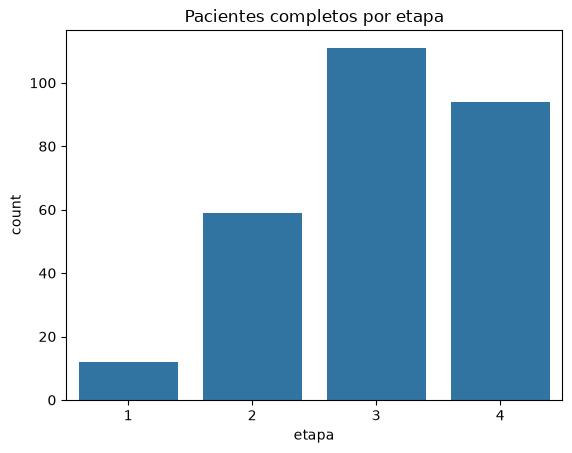

In [8]:
sns.countplot(data=completos, x=OBJETIVO)
plt.title("Pacientes completos por etapa")
plt.show()

La etapa 1 es muy rara: hay apenas 12 pacientes completos. Eso va a hacer ruidosa cualquier métrica de esa clase.

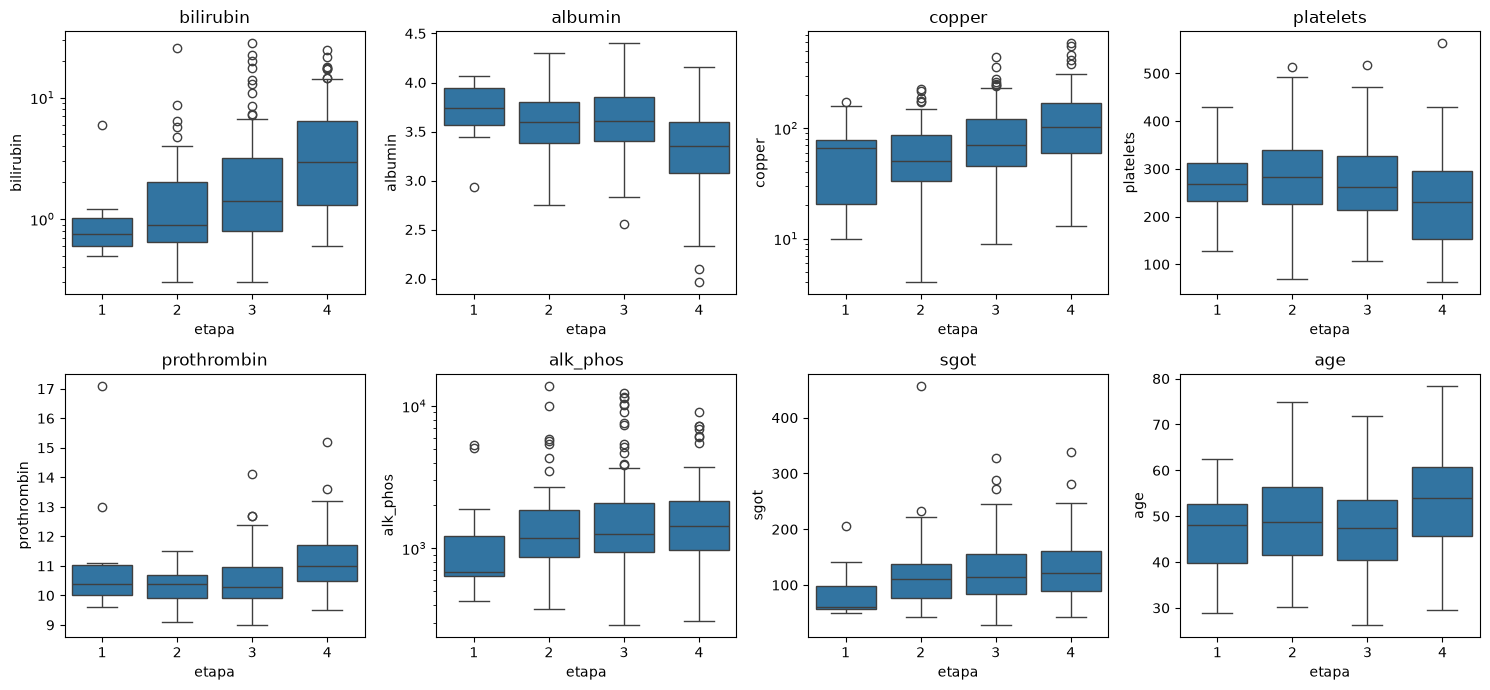

,bilirubin,albumin,platelets,prothrombin
etapa,,,,
1,0.75,3.74,267.5,10.4
2,0.90,3.60,283.0,10.4
3,1.40,3.61,263.0,10.3
4,2.95,3.36,230.5,11.0


In [9]:
fig, ejes = plt.subplots(2, 4, figsize=(15, 7))
for eje, variable in zip(ejes.ravel(), ["bilirubin", "albumin", "copper", "platelets", "prothrombin", "alk_phos", "sgot", "age"]):
    sns.boxplot(data=completos, x=OBJETIVO, y=variable, ax=eje)
    eje.set_title(variable)
    if variable in ("copper", "alk_phos", "bilirubin"):
        eje.set_yscale("log")
plt.tight_layout()
plt.show()
completos.groupby(OBJETIVO)[["bilirubin", "albumin", "platelets", "prothrombin"]].median().round(2)

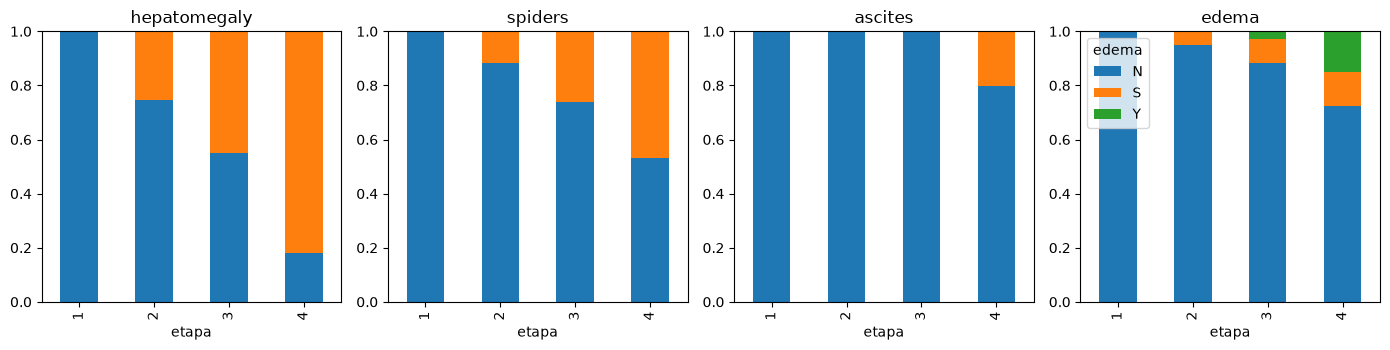

In [10]:
fig, ejes = plt.subplots(1, 4, figsize=(14, 3.6))
for eje, variable in zip(ejes, ["hepatomegaly", "spiders", "ascites", "edema"]):
    pd.crosstab(completos[OBJETIVO], completos[variable], normalize="index").plot.bar(stacked=True, ax=eje, legend=variable == "edema")
    eje.set_title(variable)
    eje.set_xlabel("etapa")
plt.tight_layout()
plt.show()

Los indicios de gravedad **crecen con la etapa**: sube la bilirrubina, baja la albúmina y aparecen más la hepatomegalia, los angiomas en araña, la ascitis y el edema. Las etapas intermedias (2 y 3) son difíciles de separar porque sus medianas se parecen.

> Analogía: es como separar las notas de un examen en cuatro grupos. Los extremos se distinguen fácil, pero entre el grupo 2 y el 3 casi nadie sabe dónde está la frontera.

---
# Sección 3: Ajuste del Modelo
---

## Modelo de Machine Learning

La división es estratificada sobre los pacientes completos.

In [11]:
train, test, y_train, y_test = train_test_split(completos, completos[OBJETIVO], test_size=0.2, stratify=completos[OBJETIVO], random_state=SEMILLA)
X_train, X_test = train[VARIABLES], test[VARIABLES]
print("Entrenamiento:", len(train), "| etapas:", y_train.value_counts().sort_index().to_dict())
print("Prueba:", len(test), "| etapas:", y_test.value_counts().sort_index().to_dict())

Entrenamiento: 220 | etapas: {1: 10, 2: 47, 3: 88, 4: 75}
Prueba: 56 | etapas: {1: 2, 2: 12, 3: 23, 4: 19}


Con solo 2 pacientes de etapa 1 en la prueba, esa clase no permite sacar conclusiones.

### Candidatos

Las clases están ponderadas (la etapa 1 tiene solo 9 pacientes en el entrenamiento), así que los puntajes **no son probabilidades calibradas**. La selección usa solo el entrenamiento, con validación cruzada estratificada repetida (5 por 4) y F1 macro.

In [12]:
def armar(estimador, variables=VARIABLES, escalar=True):
    categoricas = [v for v in variables if v in CATEGORICAS + ["status"]]
    numericas = [v for v in variables if v not in categoricas]
    columnas = ColumnTransformer([
        ("num", Pipeline([("imputar", SimpleImputer(strategy="median"))] + ([("escala", StandardScaler())] if escalar else [])), numericas),
        ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")), ("codificar", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categoricas),
    ])
    return Pipeline([("pre", columnas), ("modelo", estimador)])

def candidatos():
    return {
        "clase mayoritaria (línea base)": armar(DummyClassifier(strategy="most_frequent")),
        "regresión logística": armar(LogisticRegression(max_iter=5000, class_weight="balanced")),
        "random forest": armar(RandomForestClassifier(n_estimators=200, min_samples_leaf=3, max_depth=8, class_weight="balanced_subsample",
                                                      random_state=SEMILLA, n_jobs=-1), escalar=False),
        "gradient boosting": armar(HistGradientBoostingClassifier(max_iter=100, learning_rate=0.05, max_depth=3, class_weight="balanced",
                                                                  early_stopping=False, random_state=SEMILLA), escalar=False),
    }

validacion = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=SEMILLA)
filas = {}
for nombre, pipe in candidatos().items():
    r = cross_validate(pipe, X_train, y_train, cv=validacion, scoring={"f1": "f1_macro", "bal": "balanced_accuracy"})
    filas[nombre] = {"F1 macro cv": r["test_f1"].mean(), "desviación": r["test_f1"].std(), "exactitud balanceada cv": r["test_bal"].mean()}
comparacion = pd.DataFrame(filas).T.round(3)
comparacion

,F1 macro cv,desviación,exactitud balanceada cv
clase mayoritaria (línea base),0.143,0.003,0.250
regresión logística,0.398,0.063,0.449
random forest,0.460,0.083,0.467
gradient boosting,0.424,0.086,0.431


La desviación entre particiones es grande (0.06 a 0.09) y las diferencias entre los tres modelos reales son menores que eso. Se elige el de mayor F1 macro, pero es casi un empate.

In [13]:
ganador = comparacion.drop("clase mayoritaria (línea base)")["F1 macro cv"].idxmax()
print("Modelo elegido:", ganador)
modelo = candidatos()[ganador].fit(X_train, y_train)

Modelo elegido: random forest


##### Evaluación en el conjunto de prueba

Como la etapa es ordinal, se agregan métricas que miden **qué tan lejos** se equivoca el modelo.

In [14]:
ORDEN = [1, 2, 3, 4]

def ordinales(real, pred):
    y, p = np.asarray(real), np.asarray(pred)
    return {"exactitud": float((y == p).mean()), "F1 macro": f1_score(y, p, labels=ORDEN, average="macro", zero_division=0),
            "error medio (etapas)": float(np.abs(y - p).mean()), "a lo sumo 1 etapa de error": float((np.abs(y - p) <= 1).mean()),
            "kappa cuadrático": float(cohen_kappa_score(y, p, weights="quadratic"))}

pred = modelo.predict(X_test)
base = candidatos()["clase mayoritaria (línea base)"].fit(X_train, y_train).predict(X_test)
pd.DataFrame({"clase mayoritaria (línea base)": ordinales(y_test, base), ganador: ordinales(y_test, pred)}).T.round(3)

,exactitud,F1 macro,error medio (etapas),a lo sumo 1 etapa de error,kappa cuadrático
clase mayoritaria (línea base),0.411,0.146,0.625,0.964,0.00
random forest,0.429,0.465,0.696,0.875,0.34


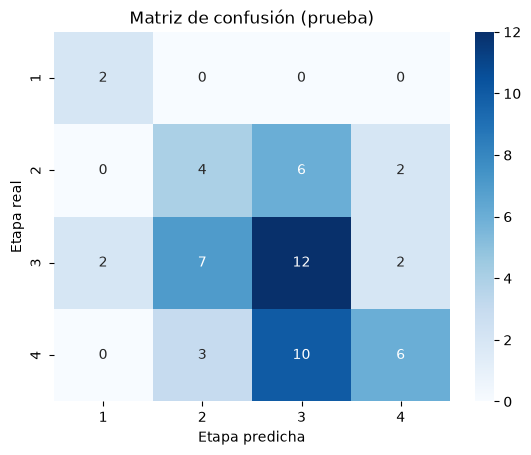

In [15]:
sns.heatmap(confusion_matrix(y_test, pred, labels=ORDEN), annot=True, fmt="d", cmap="Blues", xticklabels=ORDEN, yticklabels=ORDEN)
plt.xlabel("Etapa predicha")
plt.ylabel("Etapa real")
plt.title("Matriz de confusión (prueba)")
plt.show()

El modelo supera a la línea base en F1 macro y en kappa, pero **la línea base gana en las dos métricas de distancia** (error medio y "a lo sumo 1 etapa de error"): al predecir siempre una etapa intermedia casi nunca se equivoca por mucho. Por eso estas métricas no deben leerse solas.

### Predicciones fuera de muestra del entrenamiento

La prueba tiene solo 56 pacientes, así que se usan también las predicciones de validación cruzada sobre los 220 del entrenamiento.

In [16]:
oof = cross_val_predict(candidatos()[ganador], X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA))
print({k: round(v, 3) for k, v in ordinales(y_train, oof).items()})
pd.DataFrame(classification_report(y_train, oof, labels=ORDEN, output_dict=True, zero_division=0)).T.loc[["1", "2", "3", "4"]].round(3)

{'exactitud': 0.509, 'F1 macro': 0.484, 'error medio (etapas)': 0.564, 'a lo sumo 1 etapa de error': 0.927, 'kappa cuadrático': 0.531}


,precision,recall,f1-score,support
1,0.500,0.400,0.444,10.0
2,0.370,0.426,0.396,47.0
3,0.458,0.375,0.412,88.0
4,0.640,0.733,0.683,75.0


La etapa 4 se reconoce mejor que las intermedias, y la 1 casi no se puede evaluar. Las etapas 2 y 3 se confunden entre sí.

### ¿Sirve el seguimiento posterior?

Se vuelve a la pregunta de `N_Days` y `Status`, con regresión logística y los mismos pliegues.

In [17]:
def f1_cv(cols, datos=train):
    r = cross_val_score(armar(LogisticRegression(max_iter=5000, class_weight="balanced"), cols), datos[cols], y_train, cv=validacion, scoring="f1_macro")
    return r.mean(), r.std()

seguimiento = ["n_days", "status"]
filas = {"15 variables de la consulta inicial": f1_cv(VARIABLES), "15 + N_Days y Status": f1_cv(VARIABLES + seguimiento),
         "solo N_Days y Status": f1_cv(seguimiento)}
pd.DataFrame(filas, index=["F1 macro cv", "desviación"]).T.round(3)

,F1 macro cv,desviación
15 variables de la consulta inicial,0.398,0.063
15 + N_Days y Status,0.395,0.072
solo N_Days y Status,0.228,0.047


Agregarlos a las 15 variables **no mejora** el resultado, y solos dan un F1 apenas por encima de la línea base. No inflan la métrica, pero se excluyen por principio: no existen en la consulta.

### Qué variables usa realmente el modelo

Las medianas por etapa **describen los datos**, pero no dicen qué usa el modelo. Se mide quitando una variable a la vez.

In [18]:
completa = f1_cv(VARIABLES)[0]
diferencia = {v: f1_cv([x for x in VARIABLES if x != v])[0] - completa for v in VARIABLES}
pd.Series(diferencia).sort_values().round(4).rename("cambio de F1 macro al quitarla")

age             -0.0255
sgot            -0.0246
hepatomegaly    -0.0205
tryglicerides   -0.0161
cholesterol     -0.0052
albumin         -0.0023
ascites         -0.0013
edema            0.0015
copper           0.0016
spiders          0.0018
sex              0.0022
bilirubin        0.0027
platelets        0.0043
alk_phos         0.0083
prothrombin      0.0127
Name: cambio de F1 macro al quitarla, dtype: float64

Ninguna variable aporta más de unas pocas centésimas de F1 al quitarla, y las diferencias son menores que la desviación entre particiones. El modelo reparte su información entre variables redundantes. Por eso **no se debe afirmar** que una variable en particular "es la que importa" solo porque se vea distinta entre etapas.

### Predicción para un paciente nuevo

In [19]:
paciente = pd.DataFrame([{"age": 55.0, "bilirubin": 1.8, "cholesterol": 320.0, "albumin": 3.5, "copper": 90.0, "alk_phos": 1800.0, "sgot": 110.0,
                          "tryglicerides": 120.0, "platelets": 240.0, "prothrombin": 10.8, "sex": "F", "ascites": "N", "hepatomegaly": "Y",
                          "spiders": "N", "edema": "N"}])
puntajes = {int(e): round(float(p), 3) for e, p in zip(modelo.classes_, modelo.predict_proba(paciente[VARIABLES])[0])}
print("Etapa más probable:", int(modelo.predict(paciente[VARIABLES])[0]))
print("Puntajes (no son probabilidades calibradas):", puntajes)

Etapa más probable: 4
Puntajes (no son probabilidades calibradas): {1: 0.003, 2: 0.09, 3: 0.303, 4: 0.605}


---
# Conclusiones
---

## Resultados

Con signos clínicos y análisis de laboratorio se puede estimar la etapa por encima de la línea base, pero con un error considerable: el F1 macro está alrededor de 0.4 a 0.5 y el kappa cuadrático es moderado. Las etapas extremas se reconocen mejor que las intermedias, y la etapa 1 casi no se puede evaluar por tener muy pocos pacientes.

Hay varios hallazgos metodológicos. Primero, `N_Days` y `Status` son seguimiento posterior: se midió que no inflan la métrica, pero igual se excluyen por principio. Segundo, la línea base gana en las métricas de distancia, así que las métricas ordinales no deben leerse aisladas. Tercero, describir los datos no es medir lo que el modelo usa: ninguna variable aporta mucho sola.

Limitaciones: **no es un diagnóstico**. Son pocos pacientes (276 completos, 56 en la prueba), los datos vienen de un ensayo de 1974 a 1984 y los pacientes incompletos se dejaron fuera. Los puntajes no son probabilidades calibradas.

### Referencias

> Cohen, J. (1968). Weighted kappa: Nominal scale agreement with provision for scaled disagreement or partial credit. *Psychological Bulletin*, 70(4), 213-220.
> Dickson, E. R., Grambsch, P. M., Fleming, T. R., Fisher, L. D., & Langworthy, A. (1989). Prognosis in primary biliary cirrhosis: Model for decision making. *Hepatology*, 10(1), 1-7.
> Ludwig, J., Dickson, E. R., & McDonald, G. S. (1978). Staging of chronic nonsuppurative destructive cholangitis (syndrome of primary biliary cirrhosis). *Virchows Archiv A*, 379(2), 103-112.